# 03-01 - One Field, Four Sensors

On Wednesday 23 September we fly a drone over Poe Field and photograph it at about three centimetres a pixel. Before we do, it is worth seeing what already exists of that field from above, because a great deal does. A Landsat satellite crossed it on a September morning last year at thirty metres a pixel, a Sentinel-2 satellite crosses it every few days at ten, the federal agriculture department flew it at sixty and at thirty centimetres in two summers, and the State of New Jersey flew it at one foot in the leaf-off spring of 2020. Five files, and every one of them is a picture of the same lawn.

This notebook is about what a raster file is and what it says about itself. We open the five files and ask each one for its coordinate system, its cell size, its data type and its date, and we watch one rectangle of grass become a handful of cells, a green shape, a lawn among tree crowns, and a construction site. We count pixels across the field and bytes across the town, we make the mistake that every eight bit image invites, and we shrink one picture three ways and get three different pictures. The lecture made these points on slides. Here you make them on the files, which is the only way they stick.

Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## What a raster file says about itself

In P01 and P02 every file was a table with a geometry column, one row per building or parcel. A raster is the other kind of spatial data. It is a grid of numbers, and its geometry is not stored row by row but once, as a rule: where the top left corner sits, how wide a cell is, and in which coordinate system those two facts are stated. Everything else, the position of the millionth cell included, follows from that rule by multiplication.

`rasterio` is the library that reads these files, and the first thing to do with one is to open it and ask:

In [2]:
reference = json.load(open("data/ground_truth.json"))["p03"]
print(f"the reference numbers were generated on {json.load(open('data/ground_truth.json'))['generated']} and hold {len(reference)} blocks:")
print(", ".join(sorted(reference)))

the reference numbers were generated on 2026-09-18 and hold 19 blocks:
accuracy_table, camera, control, flown, heights, ndvi, ortho, other_flights, pixels, plan, precision, relief, report, sensors, shadows, site, snapshots, target_cm, terrain


That file is the kit's memory. Every number the lecture quoted and every number the pipeline computed is in it, and every cell below prints what it computed beside the value from there, so that nothing in this kit is typed twice and any disagreement is visible rather than hidden. Now open the first raster and ask it the questions above:

In [3]:
with rasterio.open("data/naip_2023_site.tif") as src:
    print("coordinate system ", src.crs)
    print("size              ", src.width, "columns by", src.height, "rows, in", src.count, "bands")
    print("cell              ", src.res[0], src.crs.linear_units)
    print("data type         ", src.dtypes[0])
    print("bounds            ", src.bounds)
    print("transform")
    print(src.transform)

coordinate system  EPSG:26918
size               1000 columns by 1000 rows, in 4 bands
cell               0.3 metre
data type          uint8
bounds             BoundingBox(left=529214.400000017, bottom=4465799.39999999, right=529514.400000017, top=4466099.39999999)
transform
| 0.30, 0.00, 529214.40|
| 0.00,-0.30, 4466099.40|
| 0.00, 0.00, 1.00|


One file, and already most of what we need to know. It is in EPSG:26918, which is UTM zone 18 north on the North American datum, measured in metres, a system that P01 met as `meters`. It is a thousand by a thousand cells, four bands deep, and each cell is thirty centimetres. A word on words: we say cell for a square of a grid and pixel for a square of a picture or of a sensor, and since a picture is a grid the two often mean the same square; where a number could be either, the unit tells you which. The numbers are `uint8`, i.e. whole numbers from 0 to 255, one byte each. The bounds are a square 300 m on a side.

The transform is the rule. Its six numbers say that the top left corner sits at easting 529214.4 and northing 4466099.4, that moving one column to the right adds 0.3 m to the easting, and that moving one row down subtracts 0.3 m from the northing (the minus sign, because rows count downward while northings count upward). That is the entire georeferencing of a million cells.

A well made file also says where it came from. The pipeline that pinned these windows wrote the answer into the file's tags, and you should expect any raster you are handed to carry the same, or to be asked why it does not:

In [4]:
with rasterio.open("data/naip_2023_site.tif") as src:
    for key, value in src.tags().items():
        if key != "AREA_OR_POINT":
            print(f"{key:10} {value}")

bands      red, green, blue, near infrared
datetime   2023-08-20T16:00:00+00:00
gsd        0.3
item       nj_m_4007443_ne_18_030_20230820_20231019
licence    Public domain, USDA
note       the field was being rebuilt when this flight passed; the 2022 flight shows it in use
retrieved  2026-09-13
source     Planetary Computer, naip
window     300 m around the site centroid, cut from the 600 m window of 14_fetch_stac_scenes.py


The item is the catalogue's own name for the flight, the date is the day the aeroplane passed, the licence says the picture is public domain, and the note is a remark the pipeline left for you. Keep the date in mind. It will matter in a moment.

Now the same questions to all five files at once, as a table, with the band descriptions underneath because they are too long for a column and too important to shorten:

In [5]:
FILES = {
    "landsat_9":  ("Landsat 9, 30 m",   "data/landsat_20250914_site.tif",   "2025-09-14"),
    "sentinel_2": ("Sentinel-2, 10 m",  "data/s2_20250822_campus_10m.tif",  "2025-08-22"),
    "naip_2022":  ("NAIP 2022, 60 cm",  "data/naip_2022_site.tif",          "2022-07-04"),
    "naip_2023":  ("NAIP 2023, 30 cm",  "data/naip_2023_site.tif",          "2023-08-20"),
    "nj_2020":    ("NJ 2020, 1 ft",     "data/nj2020_site_1ft.tif",         "2020, leaf-off"),
}
rows = []
for key, (label, path, day) in FILES.items():
    with rasterio.open(path) as f:
        rows.append({"sensor": label, "crs": f.crs.to_string(), "columns": f.width, "rows": f.height, "bands": f.count,
                     "type": f.dtypes[0], "cell": f.res[0], "unit": f.crs.linear_units, "date": day})
print(pd.DataFrame(rows).to_string(index=False))
print()
for key, (label, path, day) in FILES.items():
    with rasterio.open(path) as f:
        print(f"{label:17} bands: {', '.join(f.descriptions)}")

          sensor        crs  columns  rows  bands    type  cell           unit           date
 Landsat 9, 30 m EPSG:32618       40    40      8 float32  30.0          metre     2025-09-14
Sentinel-2, 10 m EPSG:32618      400   400      4 float32  10.0          metre     2025-08-22
NAIP 2022, 60 cm EPSG:26918     1000  1000      4   uint8   0.6          metre     2022-07-04
NAIP 2023, 30 cm EPSG:26918     1000  1000      4   uint8   0.3          metre     2023-08-20
   NJ 2020, 1 ft  EPSG:3424     1000  1000      4   uint8   1.0 US survey foot 2020, leaf-off

Landsat 9, 30 m   bands: blue reflectance, green reflectance, red reflectance, nir08 reflectance, swir16 reflectance, swir22 reflectance, lwir11 surface temperature K, qa_pixel flags, bit 1 dilated cloud, 2 cirrus, 3 cloud, 4 shadow, 7 water
Sentinel-2, 10 m  bands: blue reflectance, green reflectance, red reflectance, nir reflectance
NAIP 2022, 60 cm  bands: red, green, blue, near infrared
NAIP 2023, 30 cm  bands: red, green, blue

Three coordinate systems for five pictures of one lawn. The two satellites are in EPSG:32618, UTM zone 18 north on the WGS 84 datum, the satellites' own system. The two NAIP flights are in EPSG:26918, the same zone on the North American datum. And the State's orthophoto is in EPSG:3424, New Jersey State Plane in US survey feet, the system every municipal layer in P02 arrived in. The cell column already tells you to read the unit column beside it, because a cell of 1 is a foot here and would be a metre two rows up.

Two data types as well. The satellites' files hold `float32`, i.e. decimal numbers, because the pipeline that pinned them converted the stored counts into reflectance, the fraction of sunlight the ground sent back. The aerial files hold `uint8`, plain eight bit brightness with no physical unit. The band list under the table is worth reading twice. The order differs from file to file, the satellites listing blue first, NAIP red first, and the State's file the near infrared band first because that is how the infrared rendering was served. And the bands are not all the same kind of thing. Six of Landsat's eight are reflectance, the seventh is a surface temperature in kelvin and the eighth a mask of quality flags, so an average over all eight would be arithmetic on three different quantities. Nothing in a raster says "this band is red" except its description, and a file without descriptions leaves you guessing, so read them before you compose a colour picture or compute anything.

Note also that the Sentinel-2 file is much larger than the others in ground terms. It is the whole 4 km campus window of the lecture, because at 10 m a 600 m box would be sixty cells on a side and not worth opening.

The two UTM systems deserve a sentence, since they will meet again on Wednesday when the drone's receiver reports in one and the terrain model of 03-04 in the other. Ask geopandas to move the field's centre from one to the other:

In [6]:
site = gpd.read_file("data/site.gpkg", layer="site")
in_nad83 = site.to_crs("EPSG:26918").geometry.centroid.iloc[0]
in_wgs84 = site.to_crs("EPSG:32618").geometry.centroid.iloc[0]
print(f"EPSG:26918  {in_nad83.x:.2f}  {in_nad83.y:.2f}")
print(f"EPSG:32618  {in_wgs84.x:.2f}  {in_wgs84.y:.2f}")
print(f"shift       {in_nad83.distance(in_wgs84):.3f} m")
print("reference  ", reference["site"]["datum"]["pyproj_default_shift_m"], "m by the default transformation, stated accuracy",
      reference["site"]["datum"]["pyproj_default_accuracy_m"], "m")
print("reference  ", reference["site"]["datum"]["itrf2014_plan_shift_m"], "m in plan and", reference["site"]["datum"]["itrf2014_height_shift_m"],
      "m in height by the time dependent transformation, epoch", reference["site"]["datum"]["itrf2014_epoch"])

EPSG:26918  529364.52  4465949.34
EPSG:32618  529364.52  4465949.34
shift       0.000 m
reference   0.0 m by the default transformation, stated accuracy 4.0 m
reference   1.25 m in plan and -1.25 m in height by the time dependent transformation, epoch 2026.73


Zero. The software moved the point by nothing at all, and that zero is not a fact about the Earth. The two datums really do differ here, by about a metre and a quarter in plan and as much again in height, and the difference grows by nearly two centimetres a year because the continent moves while the satellites' frame does not. What happened is that the library, asked to go from NAD 83 to WGS 84 without being told which realisation of WGS 84 you meant, chose the null transformation and attached to it a stated accuracy of four metres. At ten metres a pixel nobody notices. At three centimetres a pixel, a metre and a quarter is more than forty pixels, and a metre of height is the difference between a kerb and the roof of a car. When two files disagree by about a metre on Wednesday's data, this is the first suspect, and the second is the drone's receiver.

## The field in each

Let us look at the lawn itself in all five files. The site polygon comes from OpenStreetMap, and the tags of `site.gpkg` carry the ODbL credit that its licence asks for. For each file we reproject the polygon into the file's own system, cut a window around it, and compose a true colour picture from the bands the descriptions told us are red, green and blue. The stretch, which maps each band's 2nd and 98th percentile onto black and white, is only for display; the numbers underneath are untouched.

One trap lives in the next cell and in every plotting cell of this kit. `rasterio` gives a file's bounds as left, bottom, right, top, and matplotlib's `extent` wants left, right, bottom, top. The two orders look alike and swapping them flips a picture upside down without raising anything, so the order is written out every time it is used.

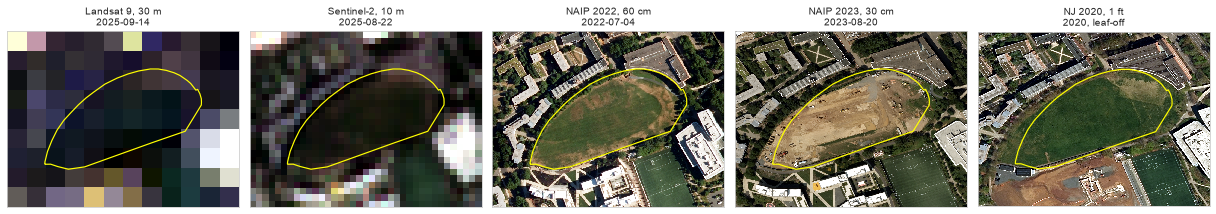

In [7]:
RGB = {"landsat_9": (3, 2, 1), "sentinel_2": (3, 2, 1), "naip_2022": (1, 2, 3), "naip_2023": (1, 2, 3), "nj_2020": (2, 3, 4)}

def metres_per_unit(f):
    '''How many metres one unit of this file's coordinate system is: 1 for metres, 0.3048 for US survey feet.'''
    return f.crs.linear_units_factor[1]

def true_colour(f, bounds, bands):
    '''Three bands of a window, stretched between their 2nd and 98th percentiles so that a picture appears, and
    returned as rows by columns by colour, the shape matplotlib wants. The stretch is for the eye only.'''
    win = from_bounds(*bounds, transform=f.transform)
    arr = f.read(bands, window=win).astype("float32")
    lo = np.nanpercentile(arr, 2, axis=(1, 2))              # one darkest value per band
    hi = np.nanpercentile(arr, 98, axis=(1, 2))             # and one brightest
    above_lo = arr - lo[:, None, None]                      # the None entries line the three values up with the three bands
    stretched = np.clip(above_lo / (hi - lo)[:, None, None], 0, 1)
    return np.moveaxis(stretched, 0, -1), f.window_bounds(win)

fig, axes = plt.subplots(1, 5, figsize=(17, 3.9))
for ax, (key, (label, path, day)) in zip(axes, FILES.items()):
    with rasterio.open(path) as f:
        field = site.to_crs(f.crs)
        pad = 60 / metres_per_unit(f)                    # 60 m of margin, in the file's own unit
        x0, y0, x1, y1 = field.total_bounds
        rgb, (left, bottom, right, top) = true_colour(f, (x0 - pad, y0 - pad, x1 + pad, y1 + pad), RGB[key])
        ax.imshow(rgb, extent=(left, right, bottom, top), interpolation="nearest")
        field.boundary.plot(ax=ax, color="yellow", linewidth=1.2)
        ax.set_title(f"{label}\n{day}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Five pictures, one lawn, and the same yellow outline on each. In the Landsat window the field is a dark smudge nine cells across, and nothing inside the outline can be told apart from anything else. In the Sentinel-2 window it is a green shape, and the roofs and the courts around it have become single bright or dark cells. At sixty centimetres, in the 2022 flight, it is a lawn with worn patches at its ends, with the courts and the roofs beside it and every tree crown as a separate blob. At thirty centimetres, in the 2023 flight, it is a construction site, because the field was being rebuilt that summer. And at one foot, in the State's flight of 2020, the turf is green but every tree is a bare grey crown, because the State flies in the leaf-off season so that the ground shows.

That is the first lesson of this kit, and it is not about resolution. Two of these pictures were taken a year apart and show a lawn and a building site. A picture has a date, and the date is part of the answer to every question you ask of it. State it.

## Cells across the field, and bytes across the town

Now we count. The field is a rectangle, and its long side divided by a file's cell size is the number of pixels the field spans in that file. For the State's file the cell is a foot, so we convert before dividing, which is exactly the step that P02 taught you never to skip:

In [8]:
field_m = site.to_crs("EPSG:26918").geometry.iloc[0]
corners = np.array(field_m.minimum_rotated_rectangle.exterior.coords)[:4]
edges = np.roll(corners, -1, axis=0) - corners          # each corner to the next, as an east and a north step
sides = np.hypot(edges[:, 0], edges[:, 1])
long_side, short_side = sides.max(), sides.min()
print(f"the field's rectangle is {long_side:.1f} by {short_side:.1f} m   reference {reference['site']['rect_length_m']} by {reference['site']['rect_width_m']}")
print()
for key, (label, path, day) in FILES.items():
    with rasterio.open(path) as f:
        cell_m = f.res[0] * metres_per_unit(f)
        print(f"{label:17} cell {cell_m:6.3f} m   {long_side / cell_m:7.1f} pixels across the field   reference {reference['sensors'][key]['pixels_across_field']}")

the field's rectangle is 270.9 by 116.7 m   reference 270.9 by 116.7

Landsat 9, 30 m   cell 30.000 m       9.0 pixels across the field   reference 9.0
Sentinel-2, 10 m  cell 10.000 m      27.1 pixels across the field   reference 27.1
NAIP 2022, 60 cm  cell  0.600 m     451.6 pixels across the field   reference 451.6
NAIP 2023, 30 cm  cell  0.300 m     903.1 pixels across the field   reference 903.1
NJ 2020, 1 ft     cell  0.305 m     888.9 pixels across the field   reference 888.9


Nine pixels, then twenty seven, then four hundred and fifty two, nine hundred and three, and eight hundred and eighty nine for the State's foot. At the drone's 2.86 cm the same side will be nine thousand five hundred pixels long. Read the steps between those numbers rather than an average of them. The first is a factor of three, the second a factor of sixteen, the third a factor of two, and the State's foot is a hair coarser than thirty centimetres, so it comes out just below. The ladder is uneven because these five sensors were never designed as a ladder; each was built for its own purpose, and we are borrowing them.

The town is 47.66 km² by the State's boundary, the number P01 computed. Divide by the cell area and you have how many cells it takes to cover Princeton at each cell size, and multiplying by the bands and the bytes per number gives the size of the file as these files are stored:

In [9]:
town = gpd.read_file("data/princeton_boundary.geojson").to_crs("EPSG:26918")
town_m2 = town.geometry.area.iloc[0]
rows = []
for key, (label, path, day) in FILES.items():
    with rasterio.open(path) as f:
        cell_m = f.res[0] * metres_per_unit(f)
        rows.append((label, cell_m, f.count, np.dtype(f.dtypes[0]).itemsize))
gsd = reference["camera"]["gsd_cm"]["80"] / 100
rows.append(("the drone at 80 m", gsd, 3, 1))

ladder = pd.DataFrame(rows, columns=["sensor", "cell_m", "bands", "bytes_per_number"])
ladder["cells"] = (town_m2 / ladder["cell_m"] ** 2).round()
ladder["megabytes"] = ladder["cells"] * ladder["bands"] * ladder["bytes_per_number"] / 1e6
ladder["reference_cells"] = [row["cells"] for row in reference["pixels"]["ladder"]]
print(f"Princeton is {town_m2 / 1e6:.2f} km2   reference {reference['pixels']['town_area_km2']} km2")
print(ladder.to_string(index=False, formatters={"cells": "{:,.0f}".format, "reference_cells": "{:,.0f}".format,
                                                "megabytes": "{:,.0f}".format, "cell_m": "{:.4f}".format}))

Princeton is 47.66 km2   reference 47.66 km2
           sensor  cell_m  bands  bytes_per_number          cells megabytes reference_cells
  Landsat 9, 30 m 30.0000      8                 4         52,954         2          52,954
 Sentinel-2, 10 m 10.0000      4                 4        476,586         8         476,586
 NAIP 2022, 60 cm  0.6000      4                 1    132,385,001       530     132,385,001
 NAIP 2023, 30 cm  0.3000      4                 1    529,540,002     2,118     512,990,851
    NJ 2020, 1 ft  0.3048      4                 1    512,990,851     2,052     529,540,002
the drone at 80 m  0.0286      3                 1 58,265,196,572   174,796  58,381,785,231


Fifty three thousand cells at Landsat's thirty metres, half a million at Sentinel's ten, a hundred and thirty million at sixty centimetres, half a billion at a foot and at thirty centimetres, and fifty eight billion at the drone's pixel. The last row is why we fly a field and not the town: the same picture of Princeton at 2.86 cm would be a hundred and seventy five gigabytes, and Wednesday's two hectares alone will be tens of millions of pixels. Two cautions about the last column. It counts the bands each sensor actually ships, eight for Landsat and three for the drone, so it compares files rather than pictures, and the reference column beside the counts is there because the drone's row uses a rounded pixel. What the column does explain is a design decision you will meet in 03-06. A file of that size is never read whole. It is read in tiles, and a reader takes only the tiles under the window it was asked for.

## Digital numbers are not reflectance

Look at the two kinds of number in these files before computing anything from them. The aerial files hold `uint8` brightness and the satellite files hold `float32` reflectance. Here are the red bands of the 2023 flight and of the August Sentinel-2 pass, as histograms:

the Sentinel-2 file says: reflectance, the item's scale and offset already applied; do not apply them again
NAIP red        uint8  from 50 to 254
Sentinel-2 red  float32  from 0.0001 to 1.6104


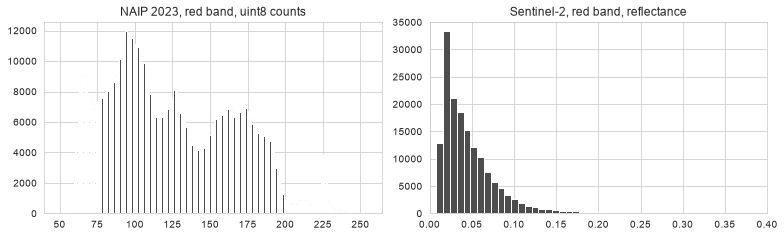

In [10]:
with rasterio.open("data/naip_2023_site.tif") as f:
    red8, nir8 = f.read(1), f.read(4)
with rasterio.open("data/s2_20250822_campus_10m.tif") as f:
    red_r = f.read(3)
    print("the Sentinel-2 file says:", f.tags()["scale_offset_note"])

print(f"NAIP red        {red8.dtype}  from {red8.min()} to {red8.max()}")
print(f"Sentinel-2 red  {red_r.dtype}  from {red_r.min():.4f} to {red_r.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(red8.ravel(), bins=256, color="0.3"); axes[0].set_title("NAIP 2023, red band, uint8 counts")
axes[1].hist(red_r.ravel(), bins=200, color="0.3"); axes[1].set_title("Sentinel-2, red band, reflectance")
axes[1].set_xlim(0, 0.4)
fig.tight_layout()

The NAIP histogram runs over whole numbers from 0 to 255, and nothing in the file says what a 120 means in sunlight. It is a rendering, adjusted by the contractor for a pleasing picture, and comparing a 120 in 2022 with a 120 in 2023 is comparing two decisions, not two amounts of light. The Sentinel-2 histogram runs from nearly zero to a few tenths for almost every cell, with a few bright roofs far above the rest, and a value of 0.05 means that five percent of the sunlight in that band came back. That is a measurement, and it can be compared across days, seasons and satellites. Note the tag: the stored counts have already been turned into reflectance by the pipeline, using the scale and the offset the catalogue lists for the item, and applying them a second time is a mistake that P04 will have every opportunity to make on live data.

The eight bit type has a second trap, and it is worth falling into once on purpose. The vegetation index you will compute in 03-02 subtracts red from near infrared and divides by their sum. Do that directly on the `uint8` arrays:

In [11]:
difference8 = nir8 - red8                        # uint8 arithmetic, on the numbers as the file stores them
total8 = nir8 + red8
difference = nir8.astype("float32") - red8       # the same two sums after one cast to decimal numbers
total = nir8.astype("float32") + red8
wrong = difference8 / total8
right = difference / total
disagree = np.abs(wrong - right) > 0.01
print(f"{disagree.mean():.1%} of the pixels come out differently")

row, col = np.argwhere(red8 > nir8)[0]           # somewhere the red band is brighter than the near infrared
print(f"a pixel where red is brighter: nir {nir8[row, col]}, red {red8[row, col]};  nir minus red in uint8 gives {difference8[row, col]}, in float {difference[row, col]}")
row, col = np.argwhere(total > 255)[0]           # and somewhere the two bands add to more than 255
print(f"a pixel where both are bright:  nir {nir8[row, col]}, red {red8[row, col]};  nir plus red in uint8 gives {total8[row, col]}, in float {total[row, col]}")

72.9% of the pixels come out differently
a pixel where red is brighter: nir 240, red 241;  nir minus red in uint8 gives 255, in float -1.0
a pixel where both are bright:  nir 214, red 214;  nir plus red in uint8 gives 172, in float 428.0


/var/folders/yk/vz7vdkds0ld4lh886p4v3lbh0000gn/T/ipykernel_58729/1441862709.py:5: RuntimeWarning: divide by zero encountered in divide
  wrong = difference8 / total8


Nearly three quarters of the pixels come out differently, and a warning about division by zero comes with them. Two things went wrong at once. An eight bit number cannot be negative, so wherever red is brighter than near infrared, on roofs, roads and bare ground, the difference wraps around to a large positive number and the roof reads as dense vegetation, which is precisely the pixel whose index you wanted to read as low. And an eight bit number cannot exceed 255, so wherever the two bands add to more than that, which is most of this bright August window, the sum wraps too, now and then to exactly zero, which is where the warning came from. Nothing raised an error at any point. The cure is one method call, `astype("float32")`, before the arithmetic, and the habit is to check the data type of any array before you do arithmetic on it.

## Shrinking a picture is a decision

A satellite does not see what an aeroplane sees and then blur it. It integrates the light over its whole cell. But we can imitate that step ourselves, and doing so shows that there is no single right way to make a picture coarser. `rasterio` can read a file into a smaller array than the file holds, and the `resampling` argument decides how each new cell is made from the old ones. Here is the 2022 flight, sixty centimetres, read at ten metres three ways:

every 10 m cell stands for 278 cells of the original


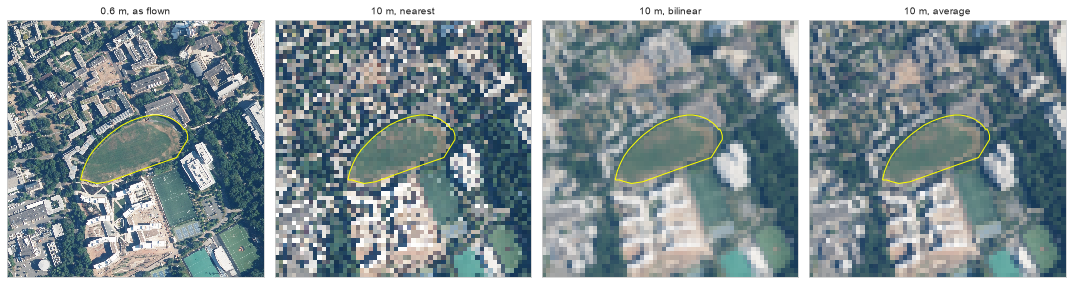

In [12]:
with rasterio.open("data/naip_2022_site.tif") as f:
    field = site.to_crs(f.crs)
    full = f.read([1, 2, 3])
    extent = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)
    coarse = {name: f.read([1, 2, 3], out_shape=(3, 60, 60), resampling=method)
              for name, method in (("nearest", Resampling.nearest), ("bilinear", Resampling.bilinear), ("average", Resampling.average))}
    cells_per_cell = (10 / f.res[0]) ** 2

def show(ax, arr, title):
    ax.imshow(np.moveaxis(arr, 0, -1), extent=extent, interpolation="nearest")
    field.boundary.plot(ax=ax, color="yellow", linewidth=1)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
show(axes[0], full, "0.6 m, as flown")
for ax, (name, arr) in zip(axes[1:], coarse.items()):
    show(ax, arr, f"10 m, {name}")
fig.tight_layout()
print(f"every 10 m cell stands for {cells_per_cell:.0f} cells of the original")

Three pictures at the same ten metres, and they are not the same picture. Nearest keeps one of the two hundred and seventy eight original cells under each new cell and throws the rest away, so the result is speckled and a tree crown survives or vanishes depending on where the grid happens to fall. Bilinear blends the four nearest cells, smoother but still a sample. Average takes the mean of all the cells under the new one, which is the honest imitation of what a coarser sensor measures, and it is why the lawn comes out uniform and the tree line soft.

Which one is right depends on what the numbers are. For a continuous quantity, brightness, reflectance, a height, average or bilinear preserve the amount and are the usual choice, and Wednesday's surface model will be resampled bilinearly for exactly that reason. For a category, a land cover class or a scene classification code, averaging two codes gives a third code that means nothing, so nearest, or the most common value, is the only defensible choice. Ask what the numbers mean before you shrink them.

## Your turn

The pixel ladder went by factors of three in the side and nine or ten in the count. Make it exact. How many NAIP 2023 cells fit inside one Sentinel-2 cell, and how many inside one Landsat cell? Then, how many Sentinel-2 cells fit inside one Landsat cell? Compute the three numbers from the cell sizes rather than guessing, and write one sentence on what the middle number says about how much a satellite averages away when it looks at a tennis court.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [13]:
# Your attempt. Read the three cell sizes off the first table, in metres, and remember that the ratio of areas is the ratio of sides squared.
#
# naip_in_sentinel = (___ / ___) ** 2
# naip_in_landsat = (___ / ___) ** 2
# sentinel_in_landsat = (___ / ___) ** 2
# print(f"{naip_in_sentinel:,.0f} NAIP cells in one Sentinel-2 cell, {naip_in_landsat:,.0f} in one Landsat cell, {sentinel_in_landsat:.0f} Sentinel-2 cells in one Landsat cell")

## Check your understanding

1. The transform of a raster is six numbers. Which of them change if the file is resampled from 30 cm to 60 cm, and which change if the same picture is saved in EPSG:3424, the State's feet?
2. The State's file reports a cell of 1 and NAIP 2023 a cell of 0.3. Which cell is smaller on the ground, and by how much? Say which column of the first table you needed to answer that.
3. A colleague computes a vegetation index on the `uint8` bands of an aerial image and reports that the parking lots come out as dense vegetation. Explain what happened, in one sentence, and name the one method call that fixes it.
4. You need a 10 m version of a land cover map whose cells hold class codes 1 to 9. Which resampling method do you choose, and what would go wrong with the others?

## Where we are

You can open a raster and read its coordinate system, its cell size, its data type, its bounds and its tags, and you know that its geometry is one rule rather than a column. You have seen the same field in three coordinate systems and two units, and watched the software move a point between two datums by exactly nothing, which you now know is a statement about the software. You can count the pixels a feature spans and the bytes a town costs at any cell size, you know the difference between a count and a reflectance, you have made the eight bit mistake once on purpose, and you know that shrinking a picture is a choice with a right answer that depends on what the numbers mean.

The habit worth keeping: before you compute anything on a raster, print its coordinate system, its cell size, its data type and its date, and say them out loud.

In 03-02 we look at the bands themselves, compose the colour infrared picture that made the golf course red in the lecture, and compute the vegetation index from reflectance at five places in town.

## Further resources

Nothing in this course requires anything below.

The rasterio quickstart is the shortest good introduction to what we did here, opening a file, reading its transform and windowing into it: https://rasterio.readthedocs.io/en/stable/quickstart.html. Its page on resampling explains every method the `Resampling` class offers: https://rasterio.readthedocs.io/en/stable/topics/resampling.html

The Sentinel-2 Level 2A products are described by the European Space Agency, including the scale and offset that turn stored counts into reflectance: https://sentiwiki.copernicus.eu/web/s2-processing. The Landsat Collection 2 Level 2 science products are documented by the USGS: https://www.usgs.gov/landsat-missions/landsat-collection-2-level-2-science-products. The National Agriculture Imagery Program is described by the USDA: https://naip-usdaonline.hub.arcgis.com/. The State's orthoimagery is served by the NJ Office of GIS: https://njogis-newjersey.opendata.arcgis.com/

The Sentinel-2 windows in this folder contain modified Copernicus Sentinel data 2025. The Landsat and NAIP files are public domain works of the US government, and the 2020 orthophoto is a public record of the State of New Jersey. The outline of Poe Field is an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The three ratios of cell areas:

```python
naip_in_sentinel = (10 / 0.3) ** 2
naip_in_landsat = (30 / 0.3) ** 2
sentinel_in_landsat = (30 / 10) ** 2
print(f"{naip_in_sentinel:,.0f} NAIP cells in one Sentinel-2 cell, {naip_in_landsat:,.0f} in one Landsat cell, {sentinel_in_landsat:.0f} Sentinel-2 cells in one Landsat cell")
```

A tennis court is about 24 by 11 m, so it covers a few Sentinel-2 cells and a fraction of a Landsat cell. Eleven hundred aerial pixels become one satellite number, and the court's white lines, its blue surface and the grass beside it are averaged into a single reflectance that belongs to none of them. The lecture called that a mixed pixel, and it is the reason the satellite files say "not vegetated" about places that are partly lawn.